# 03 · EDA — FAO FAOSTAT (Producción Agrícola)
Análisis exploratorio de datos de producción agrícola para Bolivia y Colombia.  
**Fuente:** FAO FAOSTAT API (`download_faostat.py`)  
**Archivo:** `data/external/faostat/faostat_production.csv`

Productos: Soybeans, Cattle, Sugar cane, Oil palm fruit  
Elementos: `production_tonnes`, `area_harvested_ha`

## 0. Setup
Importa librerías y carga el CSV de producción agrícola de FAOSTAT. Si no existe localmente, lo descarga ejecutando `download_faostat.py`.

In [30]:
# ── Adquisición de datos: lectura local o descarga desde S3 vía Proxy ──
import os, requests
from pathlib import Path
try:
    from dotenv import load_dotenv
    load_dotenv(Path("..") / ".env")
except ImportError:
    pass

PROXY_URL = os.getenv("DATA_PROXY_URL", "https://docs.jhoanhurtado.com").rstrip("/")

def ensure_csv(proxy_rel_path: str, local_path: str):
    """Si el archivo local no existe, lo descarga desde S3 a través del proxy inverso."""
    local = Path(local_path)
    if local.exists() and local.stat().st_size > 0:
        print(f"✅ Archivo local listo: {local} ({local.stat().st_size/1e6:.1f} MB)")
        return
    
    url = f"{PROXY_URL}/{proxy_rel_path}"
    print(f"⬇ No encontrado localmente. Descargando desde S3 ({url})...")
    try:
        local.parent.mkdir(parents=True, exist_ok=True)
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(local, "wb") as f:
                for chunk in r.iter_content(chunk_size=1048576):
                    f.write(chunk)
        print(f"✅ Descarga exitosa: {local} ({local.stat().st_size/1e6:.1f} MB)")
    except Exception as e:
        print(f"⚠️ Error al descargar desde S3 proxy ({url}): {e}")
        if not local.exists():
            raise FileNotFoundError(f"❌ No se encontró el dataset en {local} ni se pudo descargar desde {url}.")

ensure_csv("deforestacion-alert-etl/external/faostat/faostat_production.csv", "../data/external/faostat/faostat_production.csv")


✅ Archivo local listo: ../data/external/faostat/faostat_production.csv (0.0 MB)


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FAO_CSV = Path('../data/external/faostat/faostat_production.csv')
RES     = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

if not FAO_CSV.exists():
    raise FileNotFoundError(f'Ejecuta scripts/download_faostat.py primero. Esperado: {FAO_CSV}')

df = pd.read_csv(FAO_CSV)
print(f'Filas: {len(df):,} | Columnas: {list(df.columns)}')
df.head()

Filas: 60 | Columnas: ['country_code', 'country_name', 'year', 'item_name', 'element', 'value', 'unit']


,country_code,country_name,year,item_name,element,value,unit
0,BOL,Bolivia (Plurinational State of),2015,Sugar cane,area_harvested_ha,145449.0,ha
1,BOL,Bolivia (Plurinational State of),2016,Sugar cane,area_harvested_ha,146009.0,ha
2,BOL,Bolivia (Plurinational State of),2017,Sugar cane,area_harvested_ha,157074.0,ha
3,BOL,Bolivia (Plurinational State of),2018,Sugar cane,area_harvested_ha,168180.0,ha
4,BOL,Bolivia (Plurinational State of),2019,Sugar cane,area_harvested_ha,174630.0,ha


## 1. Estructura y calidad
Revisa tipos de datos, nulos, productos disponibles y rango de años. Verifica que los 4 cultivos estén presentes para ambos países con sus dos elementos (producción y área cosechada).

In [32]:
print('Tipos:')
print(df.dtypes)
print('\nNulos:')
print(df.isnull().sum())
print('\nProductos disponibles:')
print(df['item_name'].unique())
print('\nElementos:')
print(df['element'].unique())
print('\nPaíses:')
print(df['country_code'].unique())
print('\nRango años:')
print(df['year'].min(), '→', df['year'].max())

Tipos:
country_code        str
country_name        str
year              int64
item_name           str
element             str
value           float64
unit                str
dtype: object

Nulos:
country_code    0
country_name    0
year            0
item_name       0
element         0
value           0
unit            0
dtype: int64

Productos disponibles:
<StringArray>
['Sugar cane', 'Oil palm fruit']
Length: 2, dtype: str

Elementos:
<StringArray>
['area_harvested_ha', 'production_tonnes']
Length: 2, dtype: str

Países:
<StringArray>
['BOL', 'COL']
Length: 2, dtype: str

Rango años:
2015 → 2024


## 2. Producción por cultivo y país
Pivotea los datos para tener una fila por (país, año) y grafica la evolución de la producción en millones de toneladas para cada cultivo. Identifica cuál commodity ejerce mayor presión sobre el bosque.

In [33]:
prod = df[df['element'] == 'production_tonnes'].copy()
prod_pivot = prod.pivot_table(index=['country_code', 'year'],
                               columns='item_name', values='value').reset_index()
print('Producción (toneladas) — primeras filas:')
prod_pivot.head(8)

Producción (toneladas) — primeras filas:


item_name,country_code,year,Oil palm fruit,Sugar cane
0,BOL,2015,NaN,7192512.00
1,BOL,2016,NaN,7374751.00
2,BOL,2017,NaN,8731675.50
3,BOL,2018,NaN,9616439.95
4,BOL,2019,NaN,9558472.00
5,BOL,2020,NaN,10094423.00
6,BOL,2021,NaN,10057104.09
7,BOL,2022,NaN,9659111.34


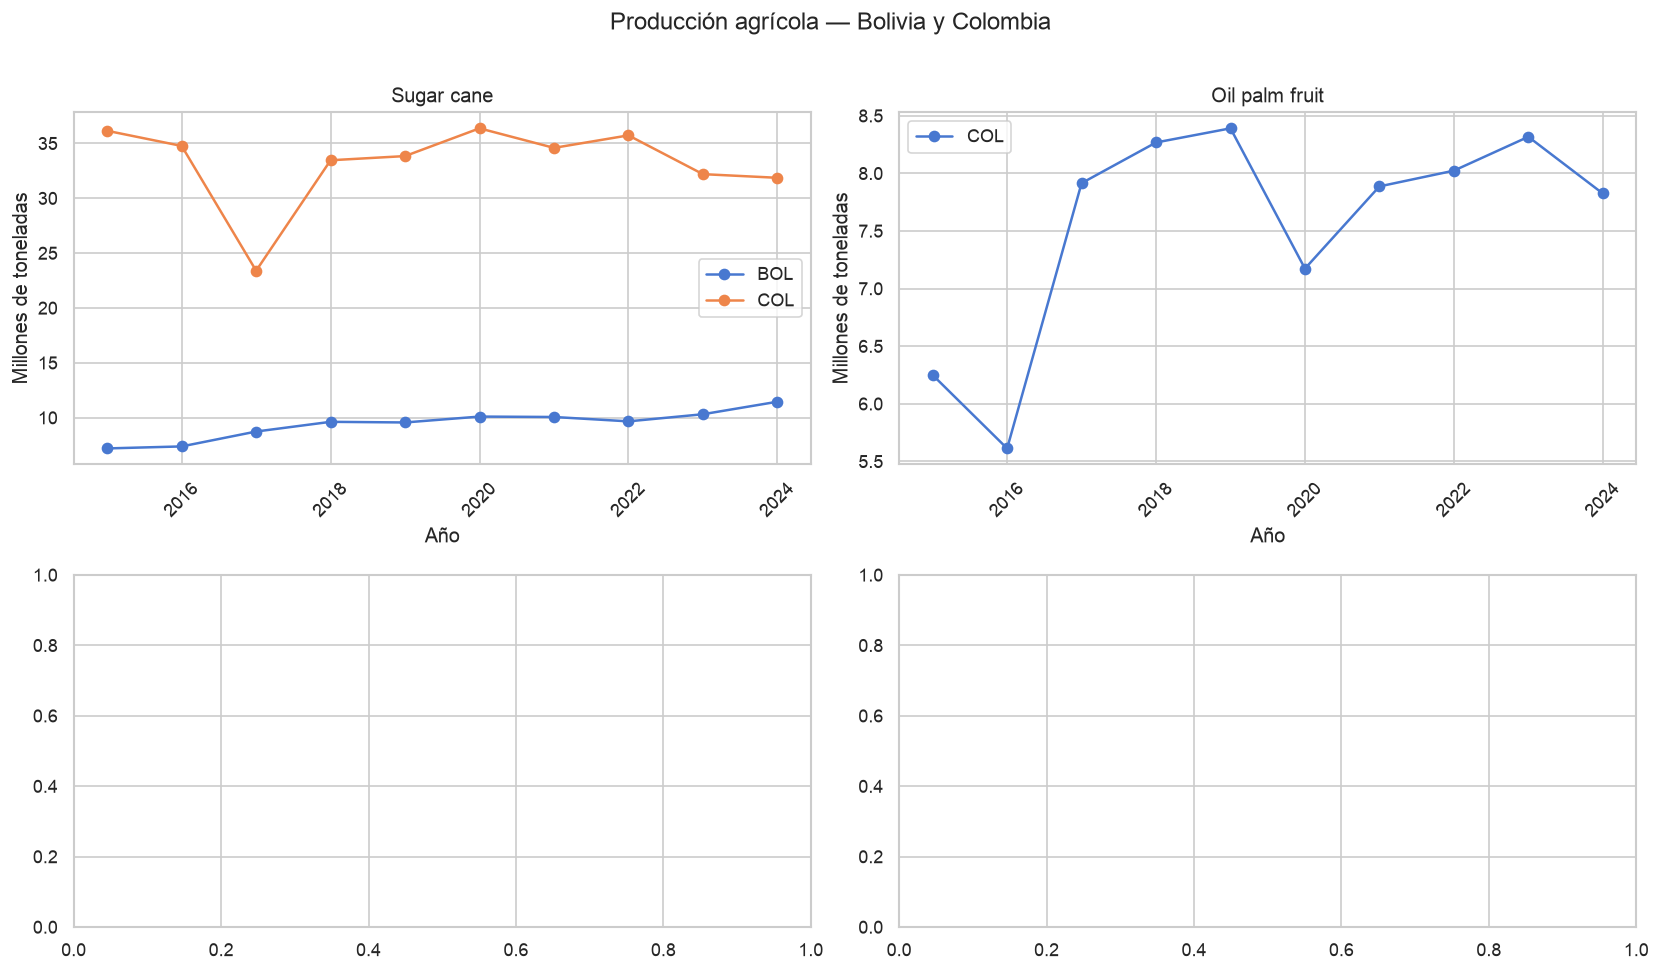

In [34]:
items = df['item_name'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, item in zip(axes, items):
    sub = df[(df['item_name'] == item) & (df['element'] == 'production_tonnes')]
    for country, grp in sub.groupby('country_code'):
        grp_s = grp.sort_values('year')
        ax.plot(grp_s['year'], grp_s['value'] / 1e6, marker='o', label=country)
    ax.set_title(item)
    ax.set_xlabel('Año')
    ax.set_ylabel('Millones de toneladas')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Producción agrícola — Bolivia y Colombia', y=1.01)
plt.tight_layout()
plt.savefig(RES / 'eda_faostat_produccion.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Área cosechada — presión sobre el territorio
Visualiza la expansión del área cosechada en miles de hectáreas por cultivo y país. El área cosechada es el indicador más directo de conversión de tierra forestal a uso agrícola.

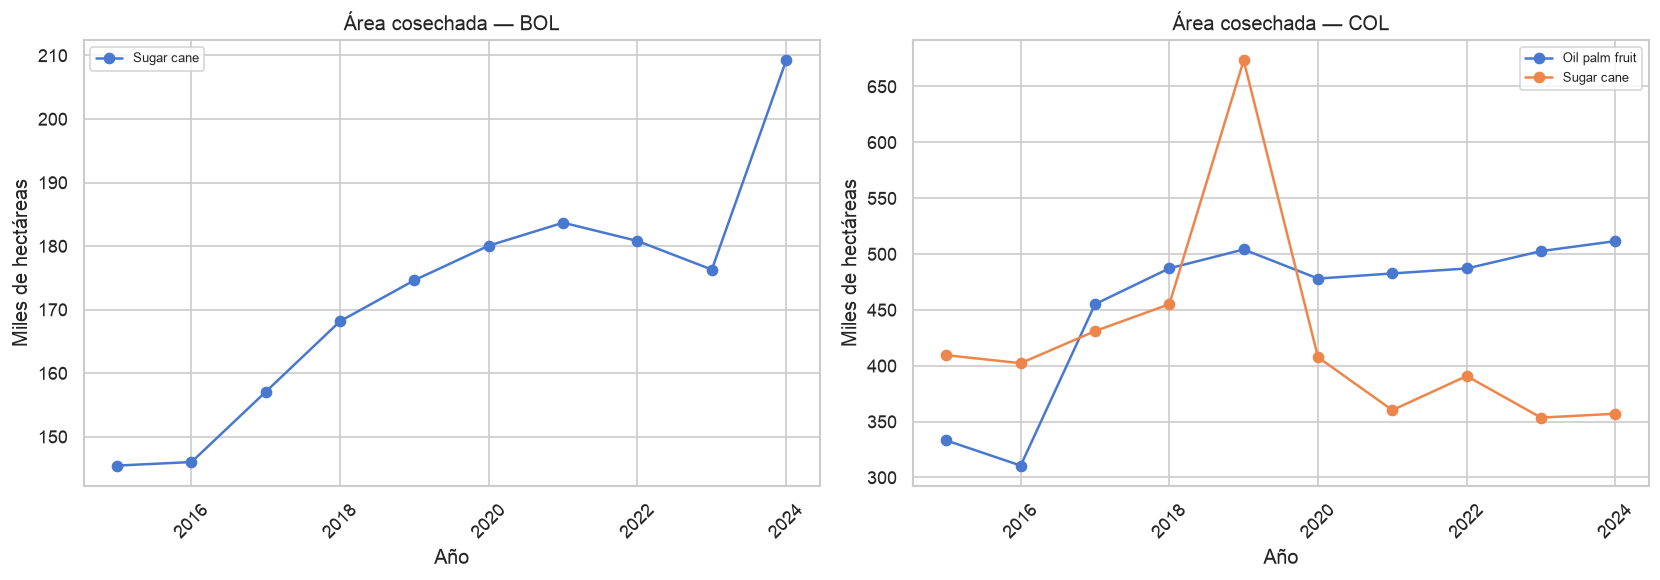

In [35]:
area = df[df['element'] == 'area_harvested_ha'].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, country in zip(axes, ['BOL', 'COL']):
    sub = area[area['country_code'] == country]
    for item, grp in sub.groupby('item_name'):
        grp_s = grp.sort_values('year')
        ax.plot(grp_s['year'], grp_s['value'] / 1e3, marker='o', label=item)
    ax.set_title(f'Área cosechada — {country}')
    ax.set_xlabel('Año')
    ax.set_ylabel('Miles de hectáreas')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RES / 'eda_faostat_area_cosechada.png', dpi=120)
plt.show()

## 4. Hallazgos y decisiones de transformación
Tabla resumen de hallazgos y decisiones de transformación para el pipeline.

| Hallazgo | Decisión |
|----------|----------|
| Soya domina el área cosechada en Bolivia (>1M ha) | Cruzar con `is_soy_area` de alertas GFW |
| Ganadería (cattle) no tiene área cosechada, solo producción | Usar producción como proxy de presión ganadera |
| Palma de aceite crece sostenidamente en Colombia | Correlacionar con alertas en departamentos productores |
| Datos anuales sin nulos para 2015–2024 | Usar directamente; granularidad país-año |
| Unidades heterogéneas (t, ha) | Normalizar por país antes de correlacionar con alertas |

## Análisis extendido
Composición de producción por cultivo (área apilada) y variación año a año (YoY) por commodity para identificar años de expansión acelerada.

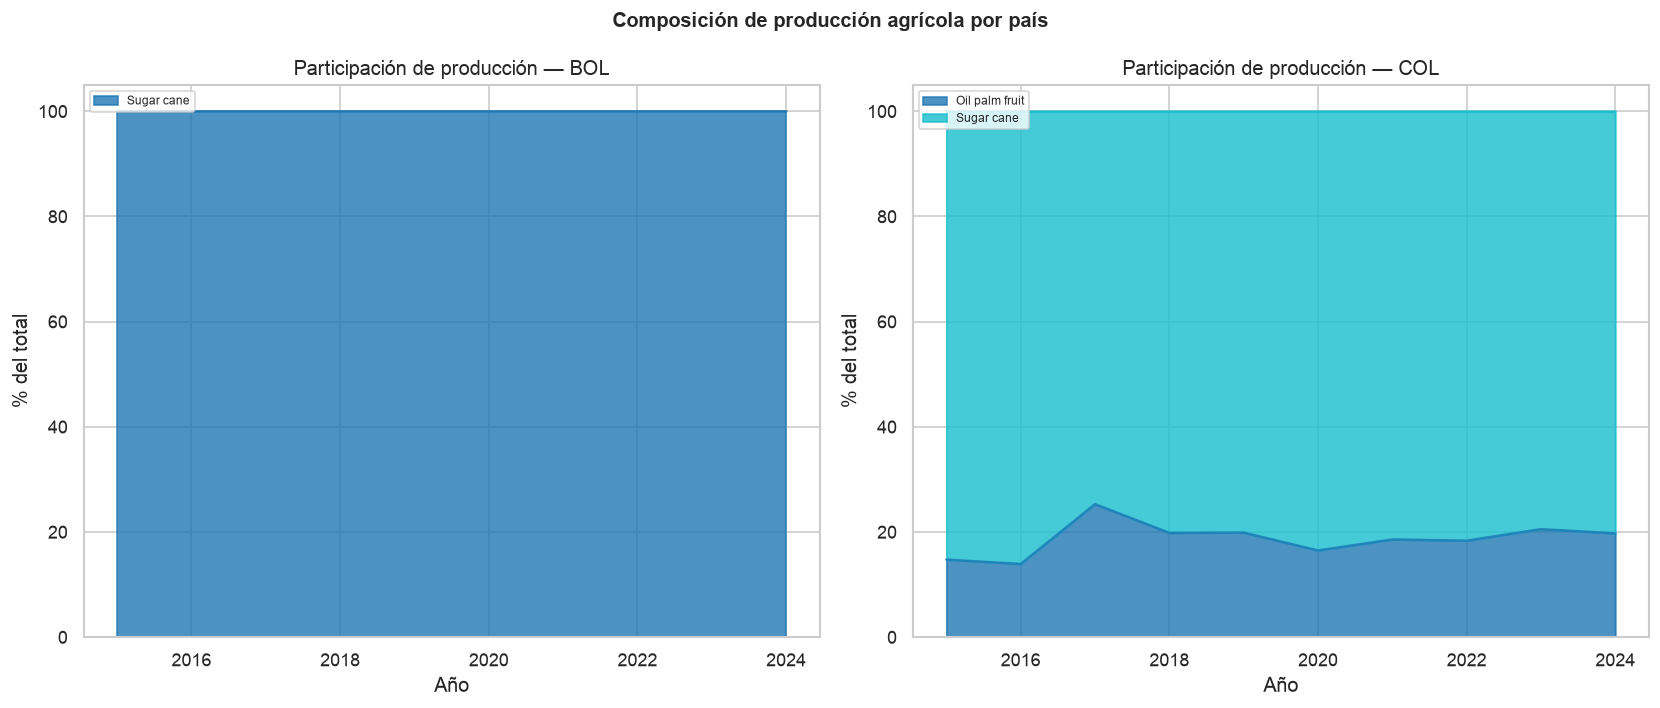

Guardado: eda_faostat_extended.png


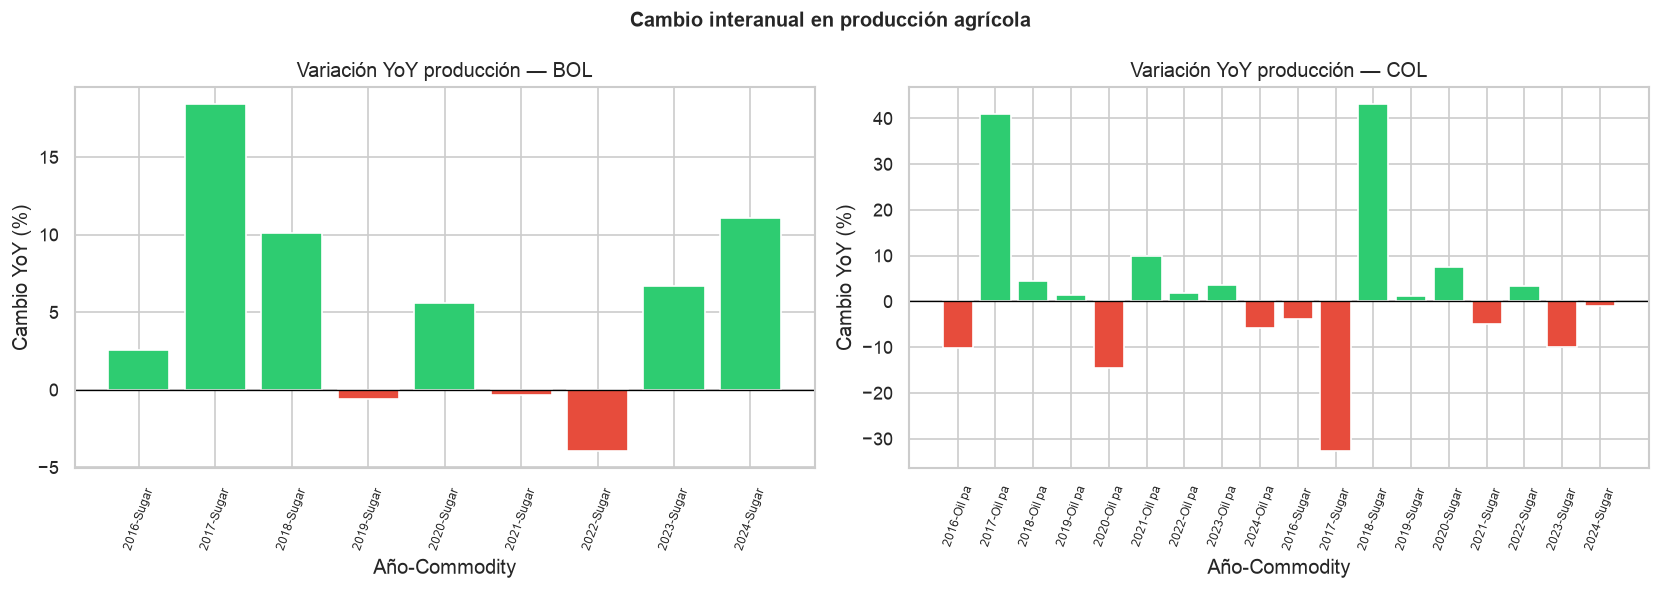

Guardado: eda_faostat_yoy.png


In [36]:
# Análisis extendido FAOSTAT
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
RES = Path('../data/results')
RES.mkdir(parents=True, exist_ok=True)

fao_path_ext = Path('../data/external/faostat/faostat_production.csv')
if fao_path_ext.exists():
    fao_ext = pd.read_csv(fao_path_ext)
    fao_cols = {c.lower(): c for c in fao_ext.columns}
    area_col = next((v for k, v in fao_cols.items() if ('country' in k or 'area' in k) and 'harvest' not in k), None)
    item_col = next((v for k, v in fao_cols.items() if 'item' in k and 'code' not in k), None)
    year_col_fao = next((v for k, v in fao_cols.items() if 'year' in k), None)
    val_col = next((v for k, v in fao_cols.items() if any(x in k for x in ('value', 'production', 'quantity'))), None)
    elem_col = next((v for k, v in fao_cols.items() if 'elem' in k), None)

    if all([area_col, item_col, year_col_fao, val_col]):
        countries_fao = fao_ext[area_col].unique()[:2]
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ax, cc in zip(axes, countries_fao):
            if elem_col and 'production_tonnes' in fao_ext[elem_col].values:
                sub = fao_ext[(fao_ext[area_col] == cc) & (fao_ext[elem_col] == 'production_tonnes')]
            else:
                sub = fao_ext[fao_ext[area_col] == cc]
            pvt = sub.groupby([year_col_fao, item_col])[val_col].sum().unstack(fill_value=0)
            pct = pvt.div(pvt.sum(axis=1), axis=0) * 100
            pct.plot(kind='area', stacked=True, ax=ax, colormap='tab10', alpha=0.8)
            ax.set_title(f'Participación de producción — {cc}')
            ax.set_xlabel('Año'); ax.set_ylabel('% del total')
            ax.legend(fontsize=7, loc='upper left')
        plt.suptitle('Composición de producción agrícola por país', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_faostat_extended.png', bbox_inches='tight')
        display(fig)
        plt.close(fig)
        print('Guardado: eda_faostat_extended.png')

        # YoY cambio por commodity
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        for ax, cc in zip(axes2, countries_fao):
            if elem_col and 'production_tonnes' in fao_ext[elem_col].values:
                sub = fao_ext[(fao_ext[area_col] == cc) & (fao_ext[elem_col] == 'production_tonnes')]
            else:
                sub = fao_ext[fao_ext[area_col] == cc]
            pvt = sub.groupby([year_col_fao, item_col])[val_col].sum().unstack(fill_value=0)
            yoy = pvt.pct_change() * 100
            yoy_melt = yoy.reset_index().melt(id_vars=year_col_fao, var_name='Commodity', value_name='YoY_%')
            yoy_melt = yoy_melt.dropna()
            for idx, row in yoy_melt.iterrows():
                clr = '#e74c3c' if row['YoY_%'] < 0 else '#2ecc71'
                ax.bar(f"{int(row[year_col_fao])}-{row['Commodity'][:6]}", row['YoY_%'], color=clr)
            ax.axhline(0, color='black', linewidth=0.8)
            ax.set_title(f'Variación YoY producción — {cc}')
            ax.set_xlabel('Año-Commodity'); ax.set_ylabel('Cambio YoY (%)')
            ax.tick_params(axis='x', rotation=70, labelsize=7)
        plt.suptitle('Cambio interanual en producción agrícola', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_faostat_yoy.png', bbox_inches='tight')
        display(fig2)
        plt.close(fig2)
        print('Guardado: eda_faostat_yoy.png')
    else:
        print(f'⚠️ Columnas no encontradas: area={area_col}, item={item_col}, year={year_col_fao}, val={val_col}')
else:
    print('⚠️ faostat_production.csv no encontrado')
